In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pygraphviz import AGraph

In [2]:
methods = [
    {
        'name': 'vgg',
        'model': 'VGG16',
    },
    # {
    #     'name': 'resnet',
    #     'model': 'ResNet18',
    # },
    {
        'name': 'resnet_ultra',
        'model': 'ResNet50',
    },
    # {
    #     'name': 'resnet_sigmoid',
    #     'model': 'ResNet18 (Sigmoid)',
    # },
    {
        'name': 'vqa',
        'model': 'VQA',
    },
    # {
    #     'name': 'svm',
    #     'model': 'SVM',
    # },
    # {
    #     'name': 'log_reg',
    #     'model': 'Logistic Regression',
    # },
]

dfs = []

for method in methods:
    # Load the predictions
    preds = pd.read_csv(f'preds_{method["name"]}.csv')
    preds = preds.rename(columns={'has_cactus': f'{method["name"]}_preds'})
    preds = preds.set_index('id')

    dfs.append(preds)

# Join the predictions
joined: pd.DataFrame = dfs.pop()
for df in dfs:
    joined = joined.join(df)

joined

,vqa_preds,vgg_preds,resnet_ultra_preds
id,,,
28f1df01c205dede3924ad332bc8849c.jpg,1,1,1
f3d2f8f72847b33bea5a1e7c3846e90f.jpg,1,0,0
8dd41e4e62b3709ce3c8a7a0677048bb.jpg,1,1,1
d671866be0c224d932893b11fd367afe.jpg,0,1,0
249e8e0f5a3f95557fb6d48389ccb1ee.jpg,1,0,1
...,...,...,...
eb67416c12b195dbd52effb958f16f69.jpg,0,1,1
112e042378469ac74c8059635a09ae6f.jpg,1,1,1
50e79c8b41fafa5f5b98dd105a9f66b0.jpg,1,0,0


In [3]:
G = nx.Graph()

for i, method in enumerate(methods):
    for cmethod in methods[i + 1:]:
        equals = (joined[f'{method["name"]}_preds'] == joined[f'{cmethod["name"]}_preds']).sum()
        total = len(joined)
        agree = equals / total
        print(f'{method["model"]} and {cmethod["model"]} agree on {equals} out of {total} test images. ({agree:.2%})')

        G.add_edge(method['model'], cmethod['model'], weight=agree, wperc=f"{agree:.2%}")

VGG16 and ResNet50 agree on 3870 out of 4000 test images. (96.75%)
VGG16 and VQA agree on 2261 out of 4000 test images. (56.53%)
ResNet50 and VQA agree on 2261 out of 4000 test images. (56.53%)


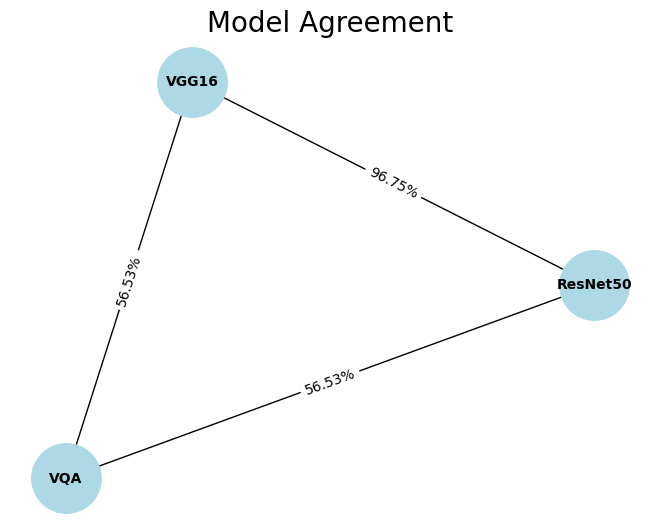

In [4]:
labels = nx.get_edge_attributes(G, 'wperc')
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
# pos['SVM'] = (-0.5, -0.5)
# pos['VGG16'] = (0.55, 0.5)
nx.draw(G, pos=pos, with_labels=True, node_size=2500, node_color='lightblue', font_size=10, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=labels, label_pos=0.5)
plt.title('Model Agreement', fontsize=20)
plt.show()

In [5]:
pos

{'VGG16': array([-0.29598877,  0.95532842]),
 'ResNet50': array([ 1.        , -0.01617829]),
 'VQA': array([-0.70401123, -0.93915013])}